# Your average cookie

I'mn doing a little data analysis project to learn data scraping, and learn more about python and data analysis.

## The data
We're investigating data scraped from allrecipes.com. The data is from 120 recipes from the search results for "cookie" (5 pages with 24 results each). We've got:
* The recipe url and title
* Average rating, and number of ratings
* Recipe details which includes the prep time and yield
* Ingredients

The data is stored in separate files as the scrapy bot was getting blocked when I tried getting them all in one go. So let's load the data and combine the pages into a single dataframe.

In [48]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATADIR = Path('cookie_recipes', 'webdata')

recipe_dataframes = []
for datafile in DATADIR.glob('allrecipes*.json'):
    df = pd.read_json(datafile)
    recipe_dataframes.append(df)

recipes = pd.concat(recipe_dataframes)

## Check the column names
recipes.columns

Index(['recipe_url', 'title', 'avg_rating', 'num_ratings', 'recipe_details',
       'ingredients'],
      dtype='str')

## Ratings
Let's look at the ratings. Below we have plotted the number of ratings versus the average rating. 

The stripes in the plot are due to the ratings all being values with exactly one decimal place. That's due to the numbers being taken from the website directly as displayed, it's not a calculated average value.

The ratings are all between 4.0 and 4.8 (this is out of 5) which suggests that the data isn't the complete set of "cookie" recipes, as surely there would be ones rated below 4.0. That claim is suppported by the results fitting five pages exactly (5 x 24 = 120), instead of the last page being partially filled. Allrecipes seemingly places a cutoff at 120 search results, likely based on the number of ratings and/or the average rating of the recipes. (The "relevance" of the search result to the query almost certainly plays a role as well.)

Lastly, the data show a trend where the rating tends toward 4.6 as the number of ratings get higher. Or in any case, allrecipes does show search results for recipes rated on the lower end (4.0 - 4.4), but not ones that also have a large number of reviews. I suspect that on the high end (rating 4.7 and 4.8), this is a real effect: When the number of ratings increases (> 10,000), there will be enough low or low-ish ratings to make the average drop slightly.

### Further research
To find out more about allrecipes cutoff on search results and/or the "real" distribution of average ratings, we could for example try a more specific search term. Searching for, say, "chocolote chip cookie" should yield results from a smaller subset of ALL recipes. We could try making the querie more-and-more specific, until we find that there are less than 120 total results, which would indicate that we have a complete subset. (Ideally, being just below 120 results).

Better yet would be to somehow get around the cutoff on search results and just get "more data". FYI, there aren't any filter options on allrecipes, so we couldn't directly request recipes rated below 4.0. (That also would still leave us with a potentially biased subset). But I have an idea...

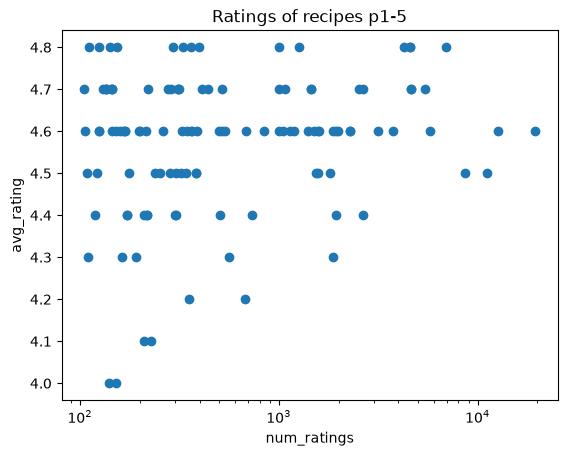

In [24]:
def plot_ratings(recipe_dataframe, title=None):
    ratings = recipe_dataframe[["avg_rating", "num_ratings"]].sort_values(by = "num_ratings")

    fig, ax = plt.subplots()
    ax.set_title(title)
    ax.set_xscale('log')
    ax.set_xlabel("num_ratings")
    ax.set_ylabel("avg_rating")
    ax.scatter(ratings["num_ratings"], ratings["avg_rating"])

    return fig, ax

fig, ax = plot_ratings(recipes, title='Ratings of recipes p1-5')

## More DATA!

...I noticed that the urls for the results pages (except the first) have a query parameter `offset=[N]`, where N=24 for the second page, 48 for the third, 72 for the fourth, and 96 for the sixth. There isn't a *button* to go to page six, but if we just put `offset=120` into the url that *does* gives us a new page of results! Neat. 

So anyway I started jamming numbers into the url just to see how many results there really were. At offset=7000 there results are less "cookie recipe" and more "What is Demerara Sugar and How Can You Use It?" At offset=8100 we get classic cookies such as "22 Best Savory Lemon Recipes for Dinner". At offset=8190 I get a results page with only four results on it, so we must conclude there are a total of 8194 search results for "cookie" on allrecipes.

### A consideration on practicality

I'm not really interested in a cookie recipe titled "The Best Cutting Boards for Meat *mdash* After Multiple Rounds of Testing". So perhaps there is some wisdom in allrecipes choice to not show us ALL search results. Moreover, I have to start a new crawl for each page to avoid blocking. That's not really practical for `ciel(8190 / 24) = 338` pages of results. So let's just do it "some more times" until I get blocked[*] and/or had enough. This turns out to be up to p12.

Let's load more data!

[*] During development, the same page and same settings would get blocked after a while. Waiting and trying again later helped.

In [ ]:
MORE_DATADIR = Path('cookie_recipes', 'more_webdata')

more_recipe_dataframes = []
for datafile in MORE_DATADIR.glob('allrecipes*.json'):
    df = pd.read_json(datafile)
    more_recipe_dataframes.append(df)

more_recipes = pd.concat(more_recipe_dataframes)
allrecipes = pd.concat([recipes, more_recipes])

more recipes:  (168, 6)
total: (288, 6)


[None]

Now, let's recreate the ratings plot with the new data (pages 6 to 12), and with the combined data.

There are indeed some recipes on the later pages with an average rating below 4.0. There are still mostly highly-rated recipes. Both plots don't give us much of a different picture than the first one.

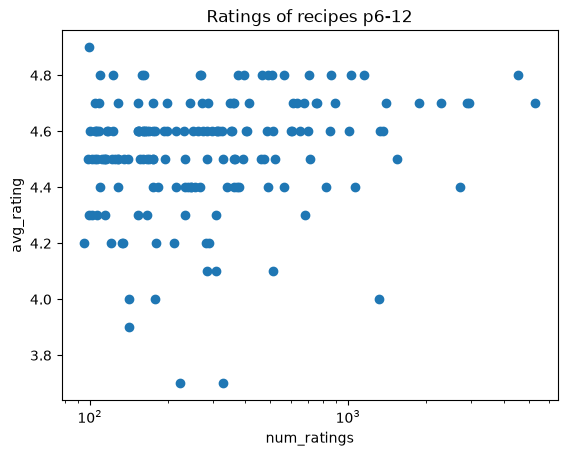

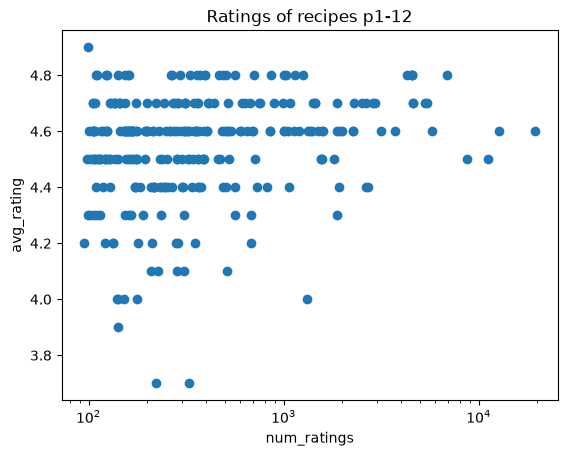

In [25]:
ax2, fig2 = plot_ratings(more_recipes, title='Ratings of recipes p6-12')
ax3, fig3 = plot_ratings(allrecipes, title='Ratings of recipes p1-12')

Let's also see if we can't detect some trends per page. First, we load the data per page/file, adding the page number as a new column before combining into a single dataframe. (First code cell below)

Then we can investigate the distribution of the *number of ratings* and the *average rating* per page. For the former, we know there are many recipe with a relatively low number of ratings, some with higher numbers, and a few outliers with a very high number of ratings. So, we view this distribution on a logarithmic scale. (Second code cell below). As we expected, overall the number of ratings decreases for higher pages. But, there is a lot of scatter. The average number of ratings on page 1 certainly is higher than the others, but after that the downward trend is not so clear.

For the average rating, we know the values are always given with one decimal (e.g. 4.5).




In [114]:
dataframes_perpage = []
pages = range(1, 13)
for page in pages:
    filename = f'allrecipes_cookies_p{page}.json'
    if page < 6:
        filepath = DATADIR.joinpath(filename)
    else:
        filepath = MORE_DATADIR.joinpath(filename)
    df = pd.read_json(filepath)
    df["page"] = page 
    dataframes_perpage.append(df)

recipes_perpage = pd.concat(dataframes_perpage)

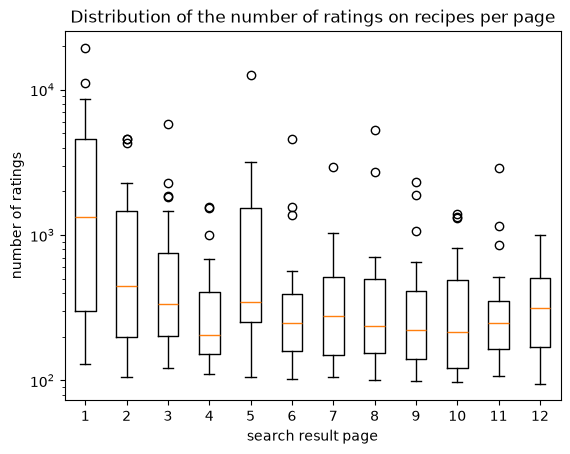

In [56]:
num_ratings_per_page = [recipes_perpage[recipes_perpage["page"] == p]["num_ratings"] for p in pages] 

fig, ax = plt.subplots()
ax.set_title("Distribution of the number of ratings on recipes per page")
ax.set_xlabel('search result page')
ax.set_ylabel('number of ratings')
ax.set_yscale('log')
boxplot = ax.boxplot(num_ratings_per_page, positions=pages)


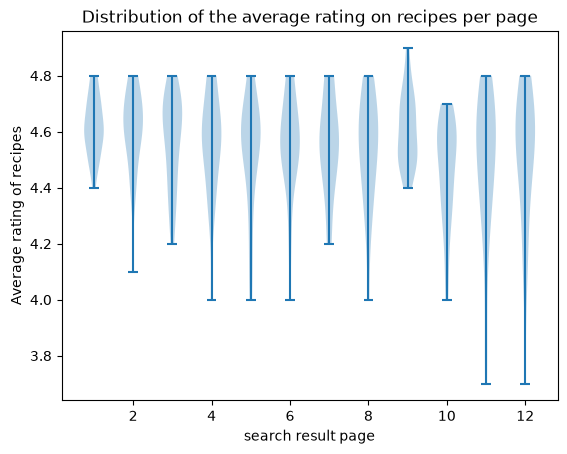

In [58]:
avg_rating_per_page = [recipes_perpage[recipes_perpage["page"] == p]["avg_rating"] for p in pages] 

fig, ax = plt.subplots()
ax.set_title("Distribution of the average rating on recipes per page")
ax.set_xlabel('search result page')
ax.set_ylabel('Average rating of recipes')
boxplot = ax.violinplot(avg_rating_per_page, positions=pages)


rating steps: [35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50]


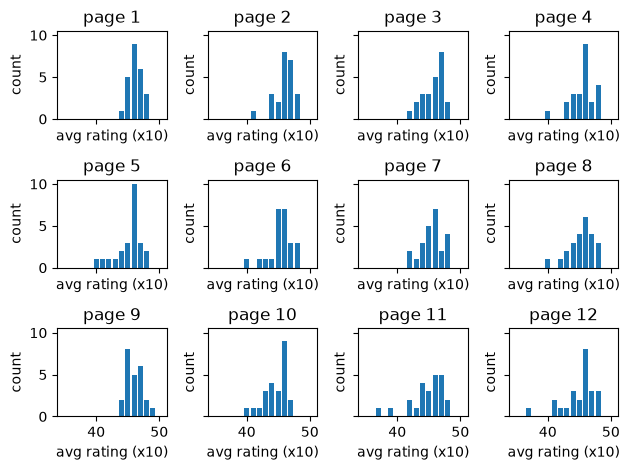

In [250]:
fig, axes = plt.subplots(3, 4, sharex=True, sharey=True)
rating_steps = np.arange(35, 51, 1)
print(f'rating steps: {rating_steps}')

for row in range(3):
    for col in range(4):
        page = 4*row + col + 1
        page_ax = axes[row][col]

        page_data = recipes_perpage[recipes_perpage["page"] == page]
        page_ratings = page_data["avg_rating"].values

        rating_counts = []
        for r in rating_steps:
            count = 0
            for rating in page_ratings:
                if int(rating*10) == r:
                    count += 1
            rating_counts.append(count)
    
        page_ax.set_title(f'page {page}')
        page_ax.set_xlabel('avg rating (x10)')
        page_ax.set_ylabel('count')
        page_ax.bar(x=rating_steps, height=rating_counts)


fig.tight_layout()

